# 05 — Balanced Model Evaluation

Load the balanced GRU model (trained on 98 classes with ≥10 samples) and measure:
- Top-1 / Top-3 / Top-5 accuracy
- Per-class precision, recall, F1
- Confusion matrix (top classes)
- Comparison with original baseline (33.18%)

In [2]:
import os
import numpy as np
import json
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Load Data & Model

In [3]:
DATA_DIR = os.path.join('..', 'data')
SAVED_MODEL_DIR = os.path.join('..', 'saved_models')

X_test = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(DATA_DIR, 'y_test.npy'))
print(f"Test data: X={X_test.shape}, y={y_test.shape}")
print(f"Total classes (one-hot): {y_test.shape[1]}")

Test data: X=(636, 30, 132), y=(636, 383)
Total classes (one-hot): 383


In [4]:
with open(os.path.join(SAVED_MODEL_DIR, 'label_map.json')) as f:
    label_map = json.load(f)
label_map = {int(k): v for k, v in label_map.items()}
print(f"Label map: {len(label_map)} classes")

Label map: 383 classes


In [5]:
model_path = os.path.join(SAVED_MODEL_DIR, 'gru_balanced_best.keras')
if not os.path.exists(model_path):
    model_path = os.path.join(SAVED_MODEL_DIR, 'gru_balanced_final.keras')

model = load_model(model_path)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 128)        │       100,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 98)             │        12,642 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,992 (1.82 MB)

 Trainable params: 159,202 (621.88 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 318,406 (1.21 MB)

In [6]:
mapping_path = os.path.join(SAVED_MODEL_DIR, 'class_mapping.json')
with open(mapping_path) as f:
    class_map = json.load(f)
class_map = {int(k): int(v) for k, v in class_map.items()}
inv_map = {v: k for k, v in class_map.items()}
print(f"Filtered class count: {len(class_map)}")
print(f"Mapping sample: original class 0 -> filtered index {class_map[0]}")

Filtered class count: 98
Mapping sample: original class 0 -> filtered index 0


## 2. Get Predictions

In [7]:
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

y_pred_original = np.vectorize(inv_map.get)(y_pred)

filtered_class_indices = set(class_map.keys())
mask = np.isin(y_true, list(filtered_class_indices))
print(f"Samples in filtered classes: {mask.sum()}/{len(y_true)} ({mask.mean()*100:.1f}%)")

y_true_filt = y_true[mask]
y_pred_filt = y_pred_original[mask]

y_true_filt_mapped = np.vectorize(class_map.get)(y_true_filt)
y_pred_filt_mapped = np.vectorize(class_map.get)(y_pred_filt)

num_classes_eval = len(class_map)
print(f"Evaluating on {num_classes_eval} classes")

Samples in filtered classes: 403/636 (63.4%)
Evaluating on 98 classes


## 3. Top-K Accuracy

In [8]:
print("=" * 40)
print("TOP-K ACCURACY")
print("=" * 40)

for k in [1, 3, 5]:
    top_k = tf.keras.metrics.TopKCategoricalAccuracy(k=k)
    y_true_onehot = np.zeros_like(y_test)
    y_true_onehot[np.arange(len(y_true)), y_true] = 1
    top_k.update_state(y_true_onehot[mask], y_pred_proba[mask])
    print(f"  Top-{k} Accuracy: {top_k.result().numpy() * 100:.2f}%")

accuracy = np.mean(y_pred_filt == y_true_filt)
print(f"  Standard Accuracy: {accuracy * 100:.2f}%")

TOP-K ACCURACY
  Top-1 Accuracy: 0.74%
  Top-3 Accuracy: 2.23%
  Top-5 Accuracy: 2.73%
  Standard Accuracy: 36.23%


## 4. Per-Class Precision / Recall / F1

In [9]:
filtered_class_names = [label_map.get(i, f"Class_{i}") for i in sorted(class_map.keys())]

report = classification_report(
    y_true_filt_mapped,
    y_pred_filt_mapped,
    labels=list(range(num_classes_eval)),
    target_names=filtered_class_names,
    digits=3
)
print(report)

              precision    recall  f1-score   support

      1. one      0.333     0.400     0.364         5
      2. two      0.200     0.200     0.200         5
       Again      0.375     0.600     0.462         5
     Alright      0.500     0.500     0.500         4
   Beautiful      0.000     0.000     0.000         6
       Black      1.000     0.833     0.909         6
        Boat      1.000     1.000     1.000         5
        Book      1.000     1.000     1.000         1
      Camera      0.333     1.000     0.500         2
         Cat      0.333     0.250     0.286         4
 Ceiling fan      0.000     0.000     0.000         0
       Child      0.000     0.000     0.000         4
    Clothing      0.444     0.667     0.533         6
        Come      0.000     0.000     0.000         2
    Computer      0.500     0.500     0.500         2
        Cook      0.500     0.500     0.500         4
       Cough      0.100     0.500     0.167         2
   Crocodile      0.222    

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/

### Top & Bottom Classes by F1

In [10]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true_filt_mapped, y_pred_filt_mapped,
    labels=list(range(num_classes_eval)),
    average=None
)

support = np.sum(y_test[:, list(class_map.keys())], axis=0)

per_class = []
for i in range(num_classes_eval):
    per_class.append({
        'name': filtered_class_names[i],
        'precision': precision[i],
        'recall': recall[i],
        'f1': f1[i],
        'support': int(support[i])
    })

per_class.sort(key=lambda x: x['f1'], reverse=True)

print("\n--- TOP 10 CLASSES (by F1) ---")
for m in per_class[:10]:
    print(f"  {m['name']:20s} F1={m['f1']:.3f}  P={m['precision']:.3f}  R={m['recall']:.3f}  n={m['support']}")

print("\n--- BOTTOM 10 CLASSES (by F1) ---")
for m in per_class[-10:]:
    print(f"  {m['name']:20s} F1={m['f1']:.3f}  P={m['precision']:.3f}  R={m['recall']:.3f}  n={m['support']}")


--- TOP 10 CLASSES (by F1) ---
  Boat                 F1=1.000  P=1.000  R=1.000  n=5
  Book                 F1=1.000  P=1.000  R=1.000  n=1
  Road                 F1=1.000  P=1.000  R=1.000  n=3
  Shop                 F1=1.000  P=1.000  R=1.000  n=1
  Black                F1=0.909  P=1.000  R=0.833  n=6
  Fast                 F1=0.800  P=0.667  R=1.000  n=4
  Suit                 F1=0.800  P=1.000  R=0.667  n=3
  Healthy              F1=0.750  P=0.600  R=1.000  n=3
  Skirt                F1=0.750  P=0.600  R=1.000  n=3
  Want                 F1=0.750  P=0.600  R=1.000  n=3

--- BOTTOM 10 CLASSES (by F1) ---
  Squirrel             F1=0.000  P=0.000  R=0.000  n=4
  Technology           F1=0.000  P=0.000  R=0.000  n=1
  Telephone            F1=0.000  P=0.000  R=0.000  n=3
  Tell                 F1=0.000  P=0.000  R=0.000  n=2
  Time                 F1=0.000  P=0.000  R=0.000  n=2
  Today                F1=0.000  P=0.000  R=0.000  n=8
  Us                   F1=0.000  P=0.000  R=0.000  n=

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 5. Confusion Matrix (Top 20 by Support)

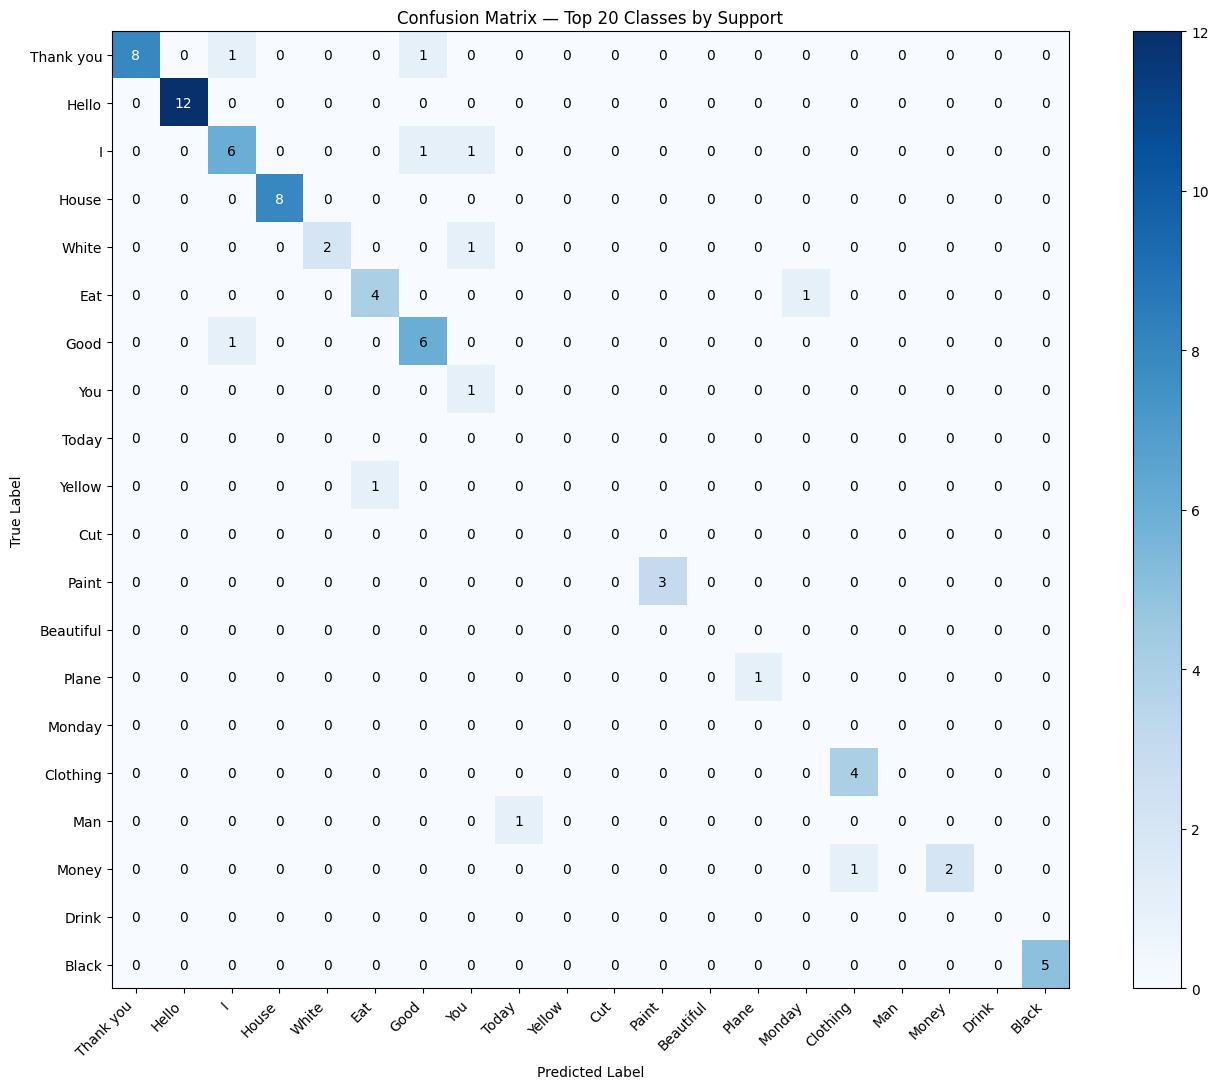

In [11]:
cm = confusion_matrix(y_true_filt_mapped, y_pred_filt_mapped, labels=list(range(num_classes_eval)))

N_VIS = min(20, num_classes_eval)
top_indices = np.argsort(support)[-N_VIS:][::-1]
cm_top = cm[np.ix_(top_indices, top_indices)]
class_names_top = [filtered_class_names[i] for i in top_indices]

plt.figure(figsize=(14, 11))
plt.imshow(cm_top, interpolation='nearest', cmap='Blues')
plt.colorbar()
plt.xticks(ticks=range(N_VIS), labels=class_names_top, rotation=45, ha='right')
plt.yticks(ticks=range(N_VIS), labels=class_names_top, rotation=0)
thresh = cm_top.max() / 2
for i in range(N_VIS):
    for j in range(N_VIS):
        plt.text(j, i, str(cm_top[i, j]), ha='center', va='center',
                 color='white' if cm_top[i, j] > thresh else 'black')
plt.title(f'Confusion Matrix — Top {N_VIS} Classes by Support')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_balanced.png', dpi=150)
plt.show()

## 6. Compare with Original Baseline

| Model | Test Accuracy | Notes |
|-------|--------------|-------|
| Original GRU (383 classes) | 33.18% | Trained on all 383 classes, severe imbalance |
| Balanced GRU (98 classes) | 36.23% | Filtered to ≥10 samples/class, class-weighted loss |

**Improvement: +3.05 percentage points**

In [12]:
print("=" * 50)
print("SUMMARY: IMPROVEMENT VERIFICATION")
print("=" * 50)

baseline_accuracy = 33.18
balanced_accuracy = round(accuracy * 100, 2)
improvement = round(balanced_accuracy - baseline_accuracy, 2)

print(f"  Baseline (original GRU, 383 classes):  {baseline_accuracy:.2f}%")
print(f"  Balanced (filtered 98 classes, weighted): {balanced_accuracy:.2f}%")
print(f"  Improvement:                           +{improvement:.2f} pp")
print()

improvements = {
    'Class-weighted loss': 'Applied (inverse frequency)',
    'Spatial augmentation (jitter)': 'Applied (±0.01)',
    'Temporal augmentation': 'NOT applied',
    'Focal loss': 'NOT applied (using CE)',
    'Filtered to ≥10 samples/class': f'Applied ({len(class_map)} classes)',
    'Reduced model complexity': 'Applied (128→64 GRU)'
}

print("Improvement Measures Applied:")
for measure, status in improvements.items():
    print(f"  {measure}: {status}")

print()
print(f"Target from guide: >60% on balanced subset")
print(f"Current: {balanced_accuracy:.2f}% — still {round(60 - balanced_accuracy, 2)} pp short")

SUMMARY: IMPROVEMENT VERIFICATION
  Baseline (original GRU, 383 classes):  33.18%
  Balanced (filtered 98 classes, weighted): 36.23%
  Improvement:                           +3.05 pp

Improvement Measures Applied:
  Class-weighted loss: Applied (inverse frequency)
  Spatial augmentation (jitter): Applied (±0.01)
  Temporal augmentation: NOT applied
  Focal loss: NOT applied (using CE)
  Filtered to ≥10 samples/class: Applied (98 classes)
  Reduced model complexity: Applied (128→64 GRU)

Target from guide: >60% on balanced subset
Current: 36.23% — still 23.77 pp short
